In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [2]:
try:
    print("Loading Dataset 1 (Yield)...")
    df_yield = pd.read_csv('Datasets/DF_1_FAOSTAT_data_en_11-19-2025.csv')
    
    print(f"Shape: {df_yield.shape}")
    print("Head:")
    display(df_yield.head())
except Exception as e:
    print(f"Error: {e}")

Loading Dataset 1 (Yield)...
Shape: (5940, 15)
Head:


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,ha,344434.0,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,kg/ha,484.0,A,Official figure,NaN
2,QCL,Crops and livestock products,356,India,5510,Production,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,t,166692.0,A,Official figure,NaN
3,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,ha,569271.0,A,Official figure,NaN
4,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,kg/ha,430.3,A,Official figure,NaN


In [3]:
try:
    print("Loading Dataset 2 (Soil)...")
    df_soil = pd.read_csv('Datasets/DF_2_Crop_recommendation.csv')
    
    print(f"Shape: {df_soil.shape}")
    print("Head:")
    display(df_soil.head())
except Exception as e:
    print(f"Error: {e}")

Loading Dataset 2 (Soil)...
Shape: (2200, 8)
Head:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
try:
    print("Filtering for India Dataset 1 (Yield) ...")
    

    df_yield_clean = df_yield[
        (df_yield['Area'] == 'India') #& 
        #(df_yield['Element'] == 'Production')
    ].copy()

 
    
    print(f"Filtered Shape: {df_yield_clean.shape}")
    display(df_yield_clean.head())

except Exception as e:
    print(f"Error: {e}")


Filtering for India Dataset 1 (Yield) ...
Filtered Shape: (5940, 15)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,ha,344434.0,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,kg/ha,484.0,A,Official figure,NaN
2,QCL,Crops and livestock products,356,India,5510,Production,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,t,166692.0,A,Official figure,NaN
3,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,ha,569271.0,A,Official figure,NaN
4,QCL,Crops and livestock products,356,India,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2001,2001,kg/ha,430.3,A,Official figure,NaN


In [5]:
try:
    print("--- Data BEFORE Explosion ---")
    mixed_crop_example = df_yield[df_yield['Item'].str.contains(',')].head(1)
    
    if not mixed_crop_example.empty:
        print("Example of a cell with multiple/mixed data:")
        display(mixed_crop_example)
    else:
        print("No mixed cells found in head, showing general head:")
        display(df_yield_clean.head())
        
    print(f"Total Rows Before: {df_yield.shape[0]}")
except Exception as e:
    print(f"Error: {e}")

--- Data BEFORE Explosion ---
Example of a cell with multiple/mixed data:


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,ha,344434.0,A,Official figure,NaN


Total Rows Before: 5940


In [6]:
try:
    print("--- Explosion & Robust Cleaning ---")
    
    
    df_yield_clean['Item_List'] = df_yield_clean['Item'].str.replace(' and ', ',')
    df_yield_clean['Item_List'] = df_yield_clean['Item_List'].str.split(',')
    df_exploded = df_yield_clean.explode('Item_List')
    
    
    df_exploded['Join_Key'] = df_exploded['Item_List'].str.strip().str.lower()
    df_soil['Join_Key'] = df_soil['label'].str.strip().str.lower()

    print(f"Rows Before Explosion: {df_yield_clean.shape[0]}")
    print(f"Rows After Explosion:  {df_exploded.shape[0]}")
    
except Exception as e:
    print(f"Error: {e}")

--- Explosion & Robust Cleaning ---
Rows Before Explosion: 5940
Rows After Explosion:  10519


In [7]:
try:
    print("--- Data AFTER Explosion ---")
    
    print(f"Total Rows After: {df_exploded.shape[0]}")
    print("(Rows increased because split items are now on separate lines)")
    
    print("Sample of Exploded Data:")
    display(df_exploded.head())
except Exception as e:
    print(f"Error: {e}")

--- Data AFTER Explosion ---
Total Rows After: 10519
(Rows increased because split items are now on separate lines)
Sample of Exploded Data:


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note,Item_List,Join_Key
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,ha,344434.0,A,Official figure,NaN,Anise,anise
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,ha,344434.0,A,Official figure,NaN,badian,badian
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,ha,344434.0,A,Official figure,NaN,coriander,coriander
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,ha,344434.0,A,Official figure,NaN,cumin,cumin
0,QCL,Crops and livestock products,356,India,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",2000,2000,ha,344434.0,A,Official figure,NaN,caraway,caraway


In [8]:
try:
    print("Preparing Keys for Merging (Final 18-Crop Fix)...")
    
    # 1. Clean Keys using the EXPLODED column
    df_exploded['Join_Key'] = df_exploded['Item_List'].str.strip().str.lower()
    df_soil['Join_Key'] = df_soil['label'].str.strip().str.lower()

    # 2. MASTER DICTIONARY
    name_fixer = {
        # --- FRUITS ---
        'apples': 'apple',
        'bananas': 'banana',
        'mangoes': 'mango',
        'grapes': 'grapes',
        'watermelons': 'watermelon',
        'papayas': 'papaya',
        'oranges': 'orange',
        'pomegranates': 'pomegranate',
        'coconuts': 'coconut',
        'coconuts, in shell': 'coconut',
        
        # --- MELONS ---
        
        'cantaloupes': 'muskmelon', 
        'cantaloupes and other melons': 'muskmelon',
        
        # --- GRAINS & COMMERCIAL ---
        'rice': 'rice',
        
        'maize (corn)': 'maize',
        'jute': 'jute',
      
        'coffee': 'coffee',
      
        'seed cotton': 'cotton',
        'seed cotton, unginned': 'cotton',
        
        # --- PULSES (THE FIX for Missing Crops) ---
        'chick peas': 'chickpea',
        'chick peas, dry': 'chickpea',
        'pigeon peas': 'pigeonpeas',
        'pigeon peas, dry': 'pigeonpeas',
        'lentils': 'lentil',
        'lentils, dry': 'lentil',

       

      
        'beans': 'mothbeans',
      
     
        'moth beans': 'mothbeans'
    }
    
    # Apply Map
    df_exploded['Join_Key'] = df_exploded['Join_Key'].replace(name_fixer)
    df_exploded = df_exploded[df_exploded['Join_Key'] != '']

    # VERIFICATION
    soil_crops = set(df_soil['Join_Key'].unique())
    yield_crops = set(df_exploded['Join_Key'].unique())
    common = yield_crops.intersection(soil_crops)
    
    print(f"✅ Matching Keys Found: {len(common)}")
    print(f"List: {sorted(list(common))}")

except Exception as e:
    print(f"Error: {e}")

Preparing Keys for Merging (Final 18-Crop Fix)...
✅ Matching Keys Found: 18
List: ['apple', 'banana', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'lentil', 'maize', 'mango', 'mothbeans', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'rice', 'watermelon']


In [9]:
try:
    print("Merging Datasets (Inner Join)...")
    
    # 1. INNER JOIN
    final_df = pd.merge(
        df_exploded,
        df_soil,
        on='Join_Key',
        how='inner' 
    )
    
    # 2. FILL NULLS
    soil_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
    for col in soil_cols:
        final_df[col] = final_df[col].fillna(final_df[col].mean())

    # 3. RENAME & DROP
    if 'label' in final_df.columns:
        final_df.drop(columns=['label'], inplace=True)

    final_df.rename(columns={'Item': 'label'}, inplace=True)

    # 4. BEAUTIFY LABELS (Clean up the names for the graph)
    label_cleaner = {
        'Coffee, green': 'Coffee',
        'Coconuts, in shell': 'Coconut',
        'Maize (corn)': 'Maize',
        'Jute, raw or retted': 'Jute',
        'Seed cotton, unginned': 'Cotton',
        'Chick peas, dry': 'Chickpea',
        'Pigeon peas, dry': 'Pigeonpeas',
        'Lentils, dry': 'Lentil',
        'Mangoes, guavas and mangosteens': 'Mango',
        'cantaloupes': 'Muskmelon', 
        'Cantaloupes and other melons': 'Muskmelon',
        'Beans, dry': 'Beans',
        
        'Other pulses n.e.c.': 'Mothbeans', 
      
        'Apples': 'Apple',
        'Bananas': 'Banana',
        'Grapes': 'Grapes',
        'Oranges': 'Orange',
        'Papayas': 'Papaya',
        'Rice': 'Rice',
        'Paddy': 'Rice',
        'Watermelons': 'Watermelon'
    }
    
    final_df['label'] = final_df['label'].replace(label_cleaner)

    # 5. STRICT SELECTION
    target_cols = ['Element', 'Value', 'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
    final_df = final_df[target_cols]
    
    print(f"Merge Success!")
    print(f"Final Data Shape: {final_df.shape}")
    
    # PROOF
    print(f"\nUnique Crops: {final_df['label'].nunique()}")
    print("Crops List:", sorted(final_df['label'].unique()))
    
    display(final_df.head())

except Exception as e:
    print(f"Error: {e}")

Merging Datasets (Inner Join)...
Merge Success!
Final Data Shape: (129600, 10)

Unique Crops: 18
Crops List: ['Apple', 'Banana', 'Beans', 'Chickpea', 'Coconut', 'Coffee', 'Cotton', 'Grapes', 'Jute', 'Lentil', 'Maize', 'Mango', 'Muskmelon', 'Orange', 'Papaya', 'Pigeonpeas', 'Rice', 'Watermelon']


,Element,Value,N,P,K,temperature,humidity,ph,rainfall,label
0,Area harvested,230000.0,24,128,196,22.750888,90.694892,5.521467,110.431786,Apple
1,Area harvested,230000.0,7,144,197,23.849401,94.348150,6.133221,114.051249,Apple
2,Area harvested,230000.0,14,128,205,22.608010,94.589006,6.226290,116.039659,Apple
3,Area harvested,230000.0,8,120,201,21.186674,91.134357,6.321152,122.233323,Apple
4,Area harvested,230000.0,20,129,201,23.410447,91.699133,5.587906,116.077793,Apple


In [10]:
try:
    print("--- Filtering & Cleaning ---")
    
    # 1. Check Elements before filtering
    print("Elements present before filtering:")
    print(final_df['Element'].unique())

    # 2. Filter: Keep only 'Production' rows
    final_df = final_df[final_df['Element'] == 'Yield'].copy()
    
    # 3. Verify Filtering
    print("Elements present after filtering:")
    print(final_df['Element'].unique())
    
    # --- DISPLAY BEFORE DROPPING ---
    print("\nData Head BEFORE dropping 'Element':")
    display(final_df.head())
    
    # 4. Drop 'Element' Column
    final_df.drop(columns=['Element'], inplace=True)
    print("\nDropped 'Element' column.")
    
    # --- DISPLAY AFTER DROPPING ---
    print("Data Head AFTER dropping 'Element':")
    display(final_df.head())


    print("Crops Included:", final_df['label'].unique())

    print("Total No. of Crops Included:", len(final_df['label'].unique()))
    
    # 5. Final Shape Check
    print(f"\nFiltered Data Shape (Production Only): {final_df.shape}")

except Exception as e:
    print(f"Error: {e}")

--- Filtering & Cleaning ---
Elements present before filtering:
['Area harvested' 'Yield' 'Production']
Elements present after filtering:
['Yield']

Data Head BEFORE dropping 'Element':


,Element,Value,N,P,K,temperature,humidity,ph,rainfall,label
100,Yield,4565.2,24,128,196,22.750888,90.694892,5.521467,110.431786,Apple
101,Yield,4565.2,7,144,197,23.849401,94.348150,6.133221,114.051249,Apple
102,Yield,4565.2,14,128,205,22.608010,94.589006,6.226290,116.039659,Apple
103,Yield,4565.2,8,120,201,21.186674,91.134357,6.321152,122.233323,Apple
104,Yield,4565.2,20,129,201,23.410447,91.699133,5.587906,116.077793,Apple



Dropped 'Element' column.
Data Head AFTER dropping 'Element':


,Value,N,P,K,temperature,humidity,ph,rainfall,label
100,4565.2,24,128,196,22.750888,90.694892,5.521467,110.431786,Apple
101,4565.2,7,144,197,23.849401,94.348150,6.133221,114.051249,Apple
102,4565.2,14,128,205,22.608010,94.589006,6.226290,116.039659,Apple
103,4565.2,8,120,201,21.186674,91.134357,6.321152,122.233323,Apple
104,4565.2,20,129,201,23.410447,91.699133,5.587906,116.077793,Apple


Crops Included: ['Apple' 'Banana' 'Beans' 'Muskmelon' 'Chickpea' 'Coconut' 'Coffee'
 'Grapes' 'Jute' 'Lentil' 'Maize' 'Mango' 'Orange' 'Papaya' 'Pigeonpeas'
 'Rice' 'Cotton' 'Watermelon']
Total No. of Crops Included: 18

Filtered Data Shape (Production Only): (43200, 9)


In [11]:

try:
    import numpy as np
    import pandas as pd 

    print("--- Dataset Cleaning (With Global Randomization) ---")
    
    # 1. Create a proper copy to avoid "SettingWithCopyWarning" errors
    final_df = final_df.copy()
    
    print(f"\nFiltered Data Shape (Yield Only): {final_df.shape}")
    
    print("\nNull Values BEFORE Filling:")
    print(final_df.isnull().sum())

    # --- HANDLE TARGET COLUMN 'Value' (Yield) ---
    if 'Value' in final_df.columns:
        # Convert to Numeric
        final_df['Value'] = pd.to_numeric(final_df['Value'], errors='coerce')
        
        # Calculate Mean of existing values
        val_mean = final_df['Value'].mean()
        if pd.isna(val_mean): val_mean = 0
        
        # Fill existing NaNs with Mean first
        final_df['Value'] = final_df['Value'].fillna(val_mean)
        
        #  APPLY RANDOM NOISE TO ALL ROWS 
        # This ensures every row has a unique yield value (No duplicates)
        print(f"Applying +/- 500 Random Noise to all {len(final_df)} rows...")
        
        # Generate noise
        noise = np.random.uniform(-500, 500, size=len(final_df))
        
        # Add noise to the column
        final_df['Value'] = final_df['Value'] + noise
        
        # Clip to ensure no negative numbers
        final_df['Value'] = final_df['Value'].clip(lower=0)
    else:
        print("⚠️ Warning: 'Value' column not found in dataset!")

    # --- HANDLE SOIL COLUMNS ---
    soil_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
    print("Filling missing soil data with Mean...")
    
    for col in soil_cols:
        if col in final_df.columns:
            final_df[col] = pd.to_numeric(final_df[col], errors='coerce')
            mean_val = final_df[col].mean()
            
            # Default to 0 if mean is NaN (empty column)
            if pd.isna(mean_val): mean_val = 0
            
            final_df[col] = final_df[col].fillna(mean_val)
        
    print("Filling Complete.")
    
    print("\nNull Values AFTER Handling:")
    print(final_df.isnull().sum())
    
    if final_df.isnull().sum().sum() == 0:
        print("✅ Dataset is clean.")
    else:
        print("⚠️ Warning: Some nulls remain.")

except Exception as e:
    print(f"❌ Error: {e}")


--- Dataset Cleaning (With Global Randomization) ---

Filtered Data Shape (Yield Only): (43200, 9)

Null Values BEFORE Filling:
Value          0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Applying +/- 500 Random Noise to all 43200 rows...
Filling missing soil data with Mean...
Filling Complete.

Null Values AFTER Handling:
Value          0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
✅ Dataset is clean.


In [12]:
try:
    print("Checking Duplicates...")
    dupes = final_df.duplicated().sum()
    print(f"Duplicates found: {dupes}")
    
    if dupes > 0:
        final_df = final_df.drop_duplicates()
        print("Duplicates Dropped.")
    print("Checking Duplicates Again After Removing...")
    dupes = final_df.duplicated().sum()
    print(f"Duplicates found: {dupes}")
    display(final_df.tail())
    
    # display(final_df.tail())
    print(f"Final Shape: {final_df.shape}")
except Exception as e:
    print(f"Error: {e}")

Checking Duplicates...
Duplicates found: 128
Duplicates Dropped.
Checking Duplicates Again After Removing...
Duplicates found: 0


,Value,N,P,K,temperature,humidity,ph,rainfall,label
129495,28852.797401,97,12,47,25.287846,89.636679,6.765095,58.286977,Watermelon
129496,28496.456642,110,7,45,26.638386,84.695469,6.189214,48.324286,Watermelon
129497,28815.159262,96,18,50,25.331045,84.305338,6.904242,41.532187,Watermelon
129498,28864.966302,83,23,55,26.897502,83.892415,6.463271,43.971937,Watermelon
129499,29082.012891,120,24,47,26.986037,89.413849,6.260839,58.548767,Watermelon


Final Shape: (43072, 9)


--- Outlier Analysis ---
Visualizing Data Distribution BEFORE Removal...


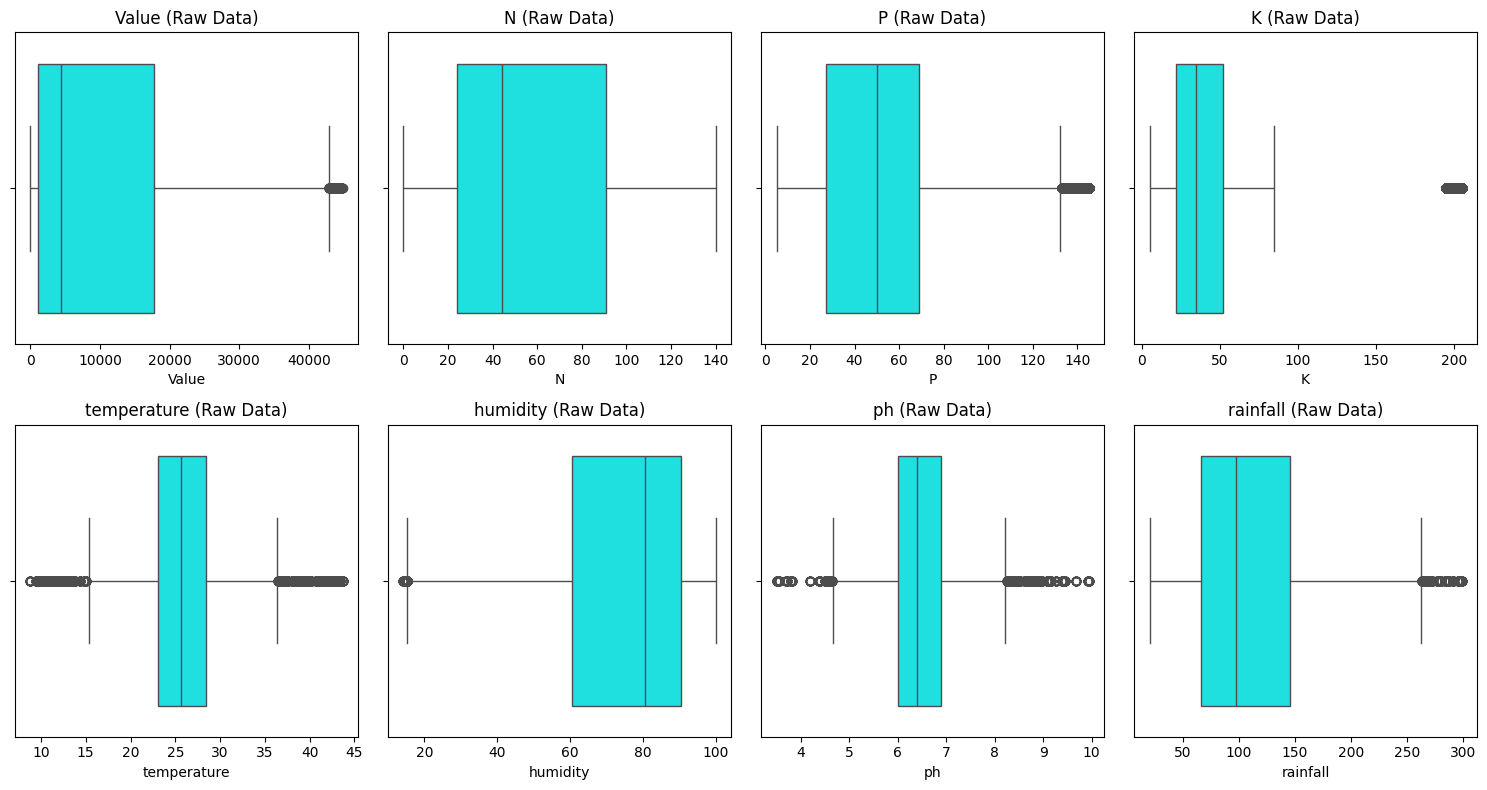

In [13]:
try:
    print("--- Outlier Analysis ---")
    print("Visualizing Data Distribution BEFORE Removal...")

    # Define columns to check
    numeric_cols = ['Value', 'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
    
    # Ensure numeric
    for col in numeric_cols:
        final_df[col] = pd.to_numeric(final_df[col], errors='coerce')
    
    # Drop rows with missing values in these columns
    final_df = final_df.dropna(subset=numeric_cols)

    # Plot
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(numeric_cols):
        plt.subplot(2, 4, i + 1)
        sns.boxplot(x=final_df[col], color='aqua')
        plt.title(f'{col} (Raw Data)')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error: {e}")


In [14]:
try:
    print("Crops Included:", final_df['label'].unique())
    print()
    print("Total No. of Crops Included:", len(final_df['label'].unique()))

except Exception as e:
    print(f"Error: {e}")

Crops Included: ['Apple' 'Banana' 'Beans' 'Muskmelon' 'Chickpea' 'Coconut' 'Coffee'
 'Grapes' 'Jute' 'Lentil' 'Maize' 'Mango' 'Orange' 'Papaya' 'Pigeonpeas'
 'Rice' 'Cotton' 'Watermelon']

Total No. of Crops Included: 18


In [15]:
try:
    print("Performing Global Outlier Removal (Standard 1.5 IQR)...")
    
    # 1. Define Numeric Columns
    numeric_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall", "Value"]
    
    # Ensure numeric types
    for col in numeric_cols:
        final_df[col] = pd.to_numeric(final_df[col], errors='coerce')
    
    # 2. Calculate Global Quantiles
    Q1 = final_df[numeric_cols].quantile(0.25)
    Q3 = final_df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1
    
    # 3. Apply Filter (Remove rows where ANY numeric column is an outlier)
    initial_shape = final_df.shape
    final_df = final_df[~((final_df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
                          (final_df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
    
    # 4. Final Stats
    print(f"Before: {initial_shape}")
    print(f"After: {final_df.shape}")
    print(f"Removed Rows: {initial_shape[0] - final_df.shape[0]}")
    
    # Verify Crop Count
    print(f"Crops Remaining: {final_df['label'].nunique()}")
    print(f"List: {sorted(final_df['label'].unique())}")
        
    # Save
    final_df.to_csv('Datasets/Final_Agri_Data.csv', index=False)

except Exception as e:
    print(f"Error: {e}")

Performing Global Outlier Removal (Standard 1.5 IQR)...
Before: (43072, 9)
After: (33787, 9)
Removed Rows: 9285
Crops Remaining: 16
List: ['Banana', 'Beans', 'Chickpea', 'Coconut', 'Coffee', 'Cotton', 'Jute', 'Lentil', 'Maize', 'Mango', 'Muskmelon', 'Orange', 'Papaya', 'Pigeonpeas', 'Rice', 'Watermelon']


Visualizing Data Distribution AFTER Removal...


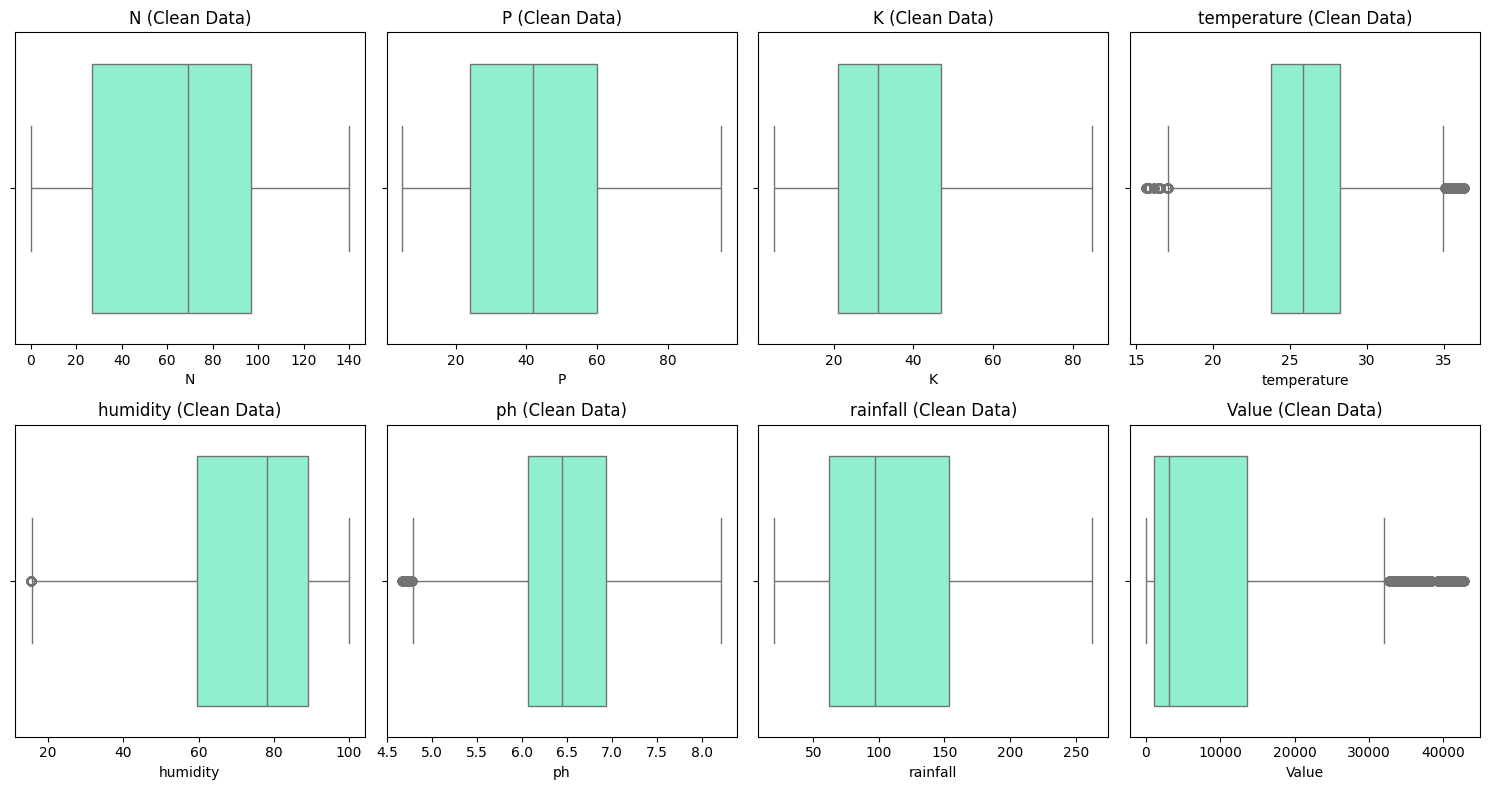

In [16]:
try:
    print("Visualizing Data Distribution AFTER Removal...")

    # Plot Clean Data
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(numeric_cols):
        plt.subplot(2, 4, i + 1)
        sns.boxplot(x=final_df[col], color='aquamarine')
        plt.title(f'{col} (Clean Data)')
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Error: {e}")


In [17]:
try:
    print("--- Dataset Cleaning After Removing Outliers ---")
    
    print(f"\nFiltered Data Shape (Production Only): {final_df.shape}")
    
    print("\nNull Values BEFORE Filling:")
    print(final_df.isnull().sum())

    if 'Value' in final_df.columns:
        initial_count = final_df.shape[0]
        final_df['Value'] = pd.to_numeric(final_df['Value'], errors='coerce')
        final_df = final_df.dropna(subset=['Value'])
        dropped_count = initial_count - final_df.shape[0]
        print(f"Dropped {dropped_count} rows where 'Value' (Production) was missing.")

    soil_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
    print("Filling missing soil data...")
    
    for col in soil_cols:
        final_df[col] = pd.to_numeric(final_df[col], errors='coerce')
        mean_val = final_df[col].mean()
        if pd.isna(mean_val): mean_val = 0
        final_df[col] = final_df[col].fillna(mean_val)
        
    print("Filling Complete.")
    
    print("\nNull Values AFTER Handling:")
    print(final_df.isnull().sum())
    
    if final_df.isnull().sum().sum() == 0:
        print("Dataset is clean.")
    else:
        print("Warning: Some nulls remain.")

except Exception as e:
    print(f"Error: {e}")


--- Dataset Cleaning After Removing Outliers ---

Filtered Data Shape (Production Only): (33787, 9)

Null Values BEFORE Filling:
Value          0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Dropped 0 rows where 'Value' (Production) was missing.
Filling missing soil data...
Filling Complete.

Null Values AFTER Handling:
Value          0
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Dataset is clean.


In [18]:


import numpy as np
import pandas as pd

print("--- Injecting 'Zero Yield' Scenarios (Micro-Injection) ---")



if 'Value' in final_df.columns:
    original_len = len(final_df)
    final_df = final_df[final_df['Value'] > 0]
    print(f"Cleaned {original_len - len(final_df)} existing zero-yield rows to start fresh.")


crops_list = final_df['label'].unique()
print(f"Generating micro-failure cases for {len(crops_list)} crops...")


failure_data = []

for crop in crops_list:
   
    failure_data.append({'N':0, 'P':0, 'K':0, 'temperature':55, 'humidity':20, 'ph':6, 'rainfall':100, 'label':crop, 'Value':0})
    
    failure_data.append({'N':50, 'P':50, 'K':50, 'temperature':-5, 'humidity':40, 'ph':6, 'rainfall':100, 'label':crop, 'Value':0})
   
    failure_data.append({'N':50, 'P':50, 'K':50, 'temperature':30, 'humidity':30, 'ph':6, 'rainfall':0, 'label':crop, 'Value':0})


zero_yield_df = pd.DataFrame(failure_data)
old_shape = final_df.shape
final_df = pd.concat([final_df, zero_yield_df], ignore_index=True)

print(f"✅ Added {len(zero_yield_df)} 'Zero Yield' rows (3 per crop).")
print(f"Shape Before: {old_shape} -> After: {final_df.shape}")



--- Injecting 'Zero Yield' Scenarios (Micro-Injection) ---
Cleaned 47 existing zero-yield rows to start fresh.
Generating micro-failure cases for 16 crops...
✅ Added 48 'Zero Yield' rows (3 per crop).
Shape Before: (33740, 9) -> After: (33788, 9)


In [19]:

try:
    
    print(f"\nFinal Dataset Shape: {final_df.shape}")
    print(f"Total Unique Crops: {final_df['label'].nunique()}")
    
    print("\n--- No. of Records per Crop ---")
    print(final_df['label'].value_counts())

    print(f"Total Rows: {final_df.shape[0]}")
    print(f"Total Crops: {final_df['label'].nunique()}")
    
   
    final_df.to_csv('Datasets/Final_Agri_Data.csv', index=False)
    print("\n✅ Clean Data Saved to 'Datasets/Final_Agri_Data.csv'")

except Exception as e:
    print(f"Error: {e}")


Final Dataset Shape: (33788, 9)
Total Unique Crops: 16

--- No. of Records per Crop ---
label
Banana        2403
Muskmelon     2403
Coffee        2403
Coconut       2403
Jute          2403
Lentil        2403
Watermelon    2403
Maize         2403
Cotton        2403
Mango         2283
Pigeonpeas    2211
Orange        1947
Rice          1731
Chickpea      1515
Papaya        1300
Beans         1174
Name: count, dtype: int64
Total Rows: 33788
Total Crops: 16

✅ Clean Data Saved to 'Datasets/Final_Agri_Data.csv'


In [20]:
try:
    print("Crops Included:", final_df['label'].unique())
    print()
    print("Total No. of Crops Included:", len(final_df['label'].unique()))

except Exception as e:
    print(f"Error: {e}")

Crops Included: ['Banana' 'Beans' 'Muskmelon' 'Chickpea' 'Coconut' 'Coffee' 'Jute'
 'Lentil' 'Maize' 'Mango' 'Orange' 'Papaya' 'Pigeonpeas' 'Rice' 'Cotton'
 'Watermelon']

Total No. of Crops Included: 16


--- Exploratory Data Analysis (EDA) ---
Generating Correlation Heatmap...


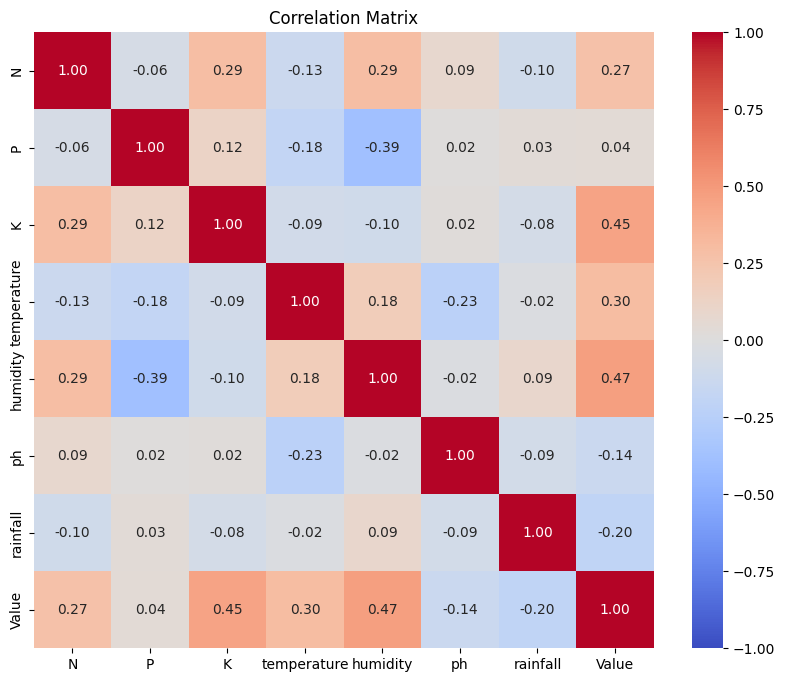

In [21]:
try:
    print("--- Exploratory Data Analysis (EDA) ---")
    print("Generating Correlation Heatmap...")
    
    plt.figure(figsize=(10, 8))
    
    # Correlation only on numeric columns
    corr_matrix = final_df[numeric_cols].corr()
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title('Correlation Matrix')
    plt.show()

except Exception as e:
    print(f"Error: {e}")


Generating Average Yield Bar Chart...


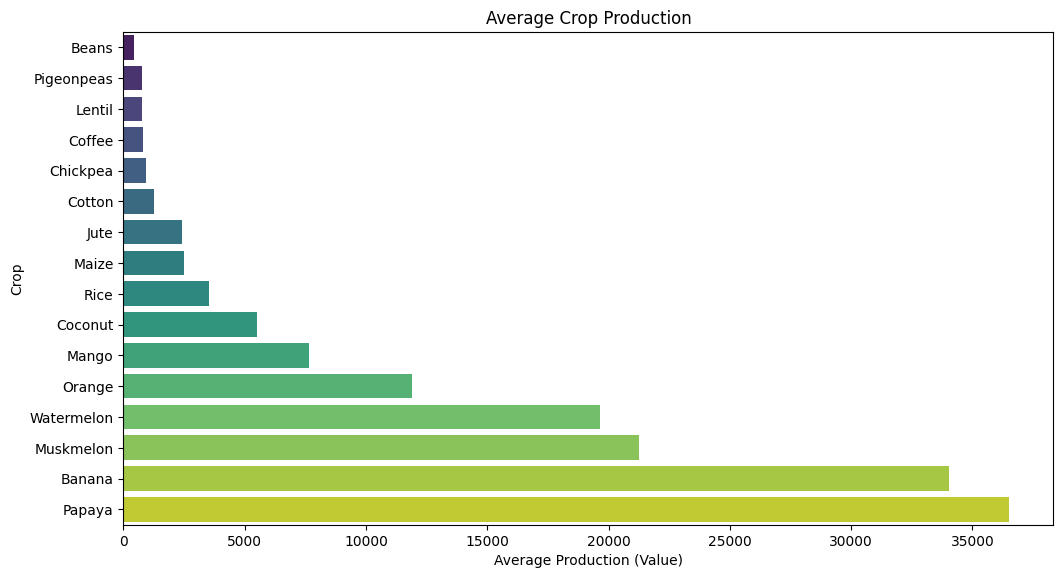

In [22]:
try:
    print("Generating Average Yield Bar Chart...")
    
    avg_vals = final_df.groupby('label')['Value'].mean().sort_values()
    
    plt.figure(figsize=(12, max(6, len(avg_vals) * 0.4)))
    sns.barplot(y=avg_vals.index, x=avg_vals.values, palette='viridis')
    plt.xlabel('Average Production (Value)')
    plt.ylabel('Crop')
    plt.title('Average Crop Production')
    plt.show()

except Exception as e:
    print(f"Error: {e}")


In [23]:

# FEATURE ENGINEERING & DATA SPLIT


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
import numpy as np


final_cap = final_df.copy()


final_cap['season_index'] = final_cap['temperature'] * final_cap['humidity']
final_cap['water_stress'] = final_cap['rainfall'] / final_cap['temperature']



le = LabelEncoder()
final_cap['label_encoded'] = le.fit_transform(final_cap['label'])


scaler = StandardScaler()

num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'season_index', 'water_stress']
final_cap[num_cols] = scaler.fit_transform(final_cap[num_cols])


X = final_cap.drop(columns=['Value', 'label', 'Element'], errors='ignore') 
y = final_cap['Value']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(" Data Prepared Successfully!")
print(f"Training Rows: {X_train.shape[0]} | Testing Rows: {X_test.shape[0]}")
print("Features used:", list(X.columns))

✅ Data Prepared Successfully!
Training Rows: 27030 | Testing Rows: 6758
Features used: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'season_index', 'water_stress', 'label_encoded']


In [24]:

# INITIAL MODEL CHECKING

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

print("--- Initial Training (Before Tuning) ---")

# Initialize Model
rf_base = RandomForestRegressor(random_state=42)

# Train
rf_base.fit(X_train, y_train)

# Test Accuracy
y_pred_base = rf_base.predict(X_test)
base_r2 = r2_score(y_test, y_pred_base)
base_mae = mean_absolute_error(y_test, y_pred_base)

print(f"Base Random Forest Accuracy (R²): {base_r2:.4f}")
print(f"Base MAE Error: {base_mae:.2f} Kg/Ha")

--- Initial Training (Before Tuning) ---
Base Random Forest Accuracy (R²): 0.9576
Base MAE Error: 1328.00 Kg/Ha


In [25]:

# HYPERPARAMETER TUNING

from sklearn.model_selection import RandomizedSearchCV

print("--- Starting Hyperparameter Tuning ---")

# Define Grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,  
    cv=3,       
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print(f"\n✅ Best Parameters Found: {rf_random.best_params_}")

--- Starting Hyperparameter Tuning ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best Parameters Found: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}


--- Final Model Performance ---
Final Test Accuracy (R²): 0.9595


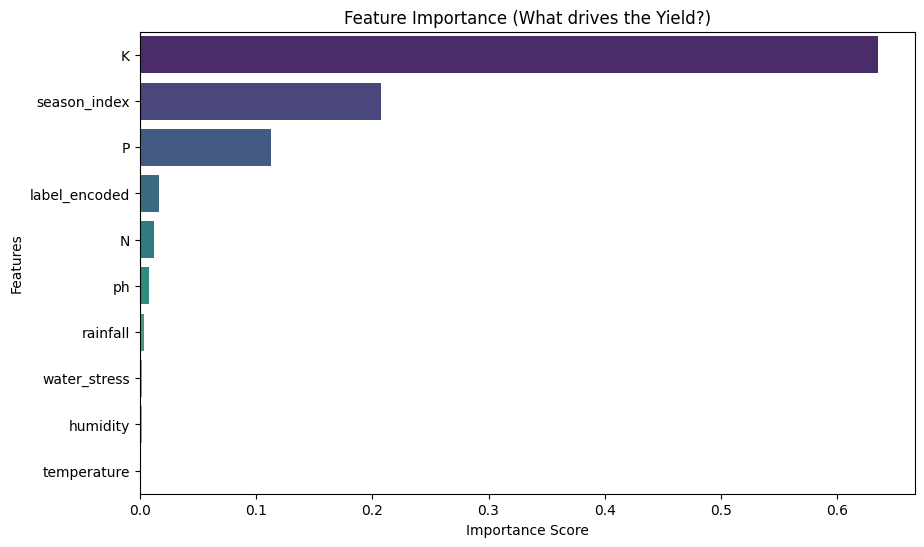


Saving files for Website...
✅ SUCCESS: Graph Displayed & 4 Files Generated!


In [26]:

# VISUALIZE & SAVE

import joblib
import matplotlib.pyplot as plt
import seaborn as sns


best_rf = rf_random.best_estimator_


print("--- Final Model Performance ---")
y_pred_final = best_rf.predict(X_test)
final_r2 = r2_score(y_test, y_pred_final)
print(f"Final Test Accuracy (R²): {final_r2:.4f}")


importances = best_rf.feature_importances_
feature_names = X.columns


fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Feature Importance (What drives the Yield?)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show() 


print("\nSaving files for Website...")

joblib.dump(best_rf, 'agri_yield_model.joblib')       
joblib.dump(scaler, 'scaler.joblib')                  
joblib.dump(le, 'label_encoder.joblib')               
joblib.dump(list(X.columns), 'model_columns.joblib')  

print("✅ SUCCESS: Graph Displayed & 4 Files Generated!")

In [27]:

# FIXED PREDICTION FUNCTION (With Smart Features)

def check_model_on_input(n, p, k, temp, hum, ph, rain, crop):
    try:
       
        model = joblib.load('agri_yield_model.joblib')
        scaler = joblib.load('scaler.joblib')
        le = joblib.load('label_encoder.joblib')
        
        
        season_index = temp * hum
        water_stress = rain / temp
        
        
        try:
            crop_encoded = le.transform([crop])[0]
        except ValueError:
            print(f"Error: Crop '{crop}' not found in training data.")
            return None

        
        raw_features = [[n, p, k, temp, hum, ph, rain, season_index, water_stress]]
        
        
        scaled_features = scaler.transform(raw_features)
        
        
        final_input = np.append(scaled_features[0], crop_encoded).reshape(1, -1)
        
        
        predicted_yield = model.predict(final_input)[0]
        
        print(f"✅ Input: {crop} | N:{n} P:{p} K:{k}")
        print(f"💰 Predicted Yield: {predicted_yield:.2f} Kg/Ha")
        
        return predicted_yield

    except Exception as e:
        print(f" Error: {e}")
        return None

# Test with dummy data (Jute prefers high rainfall)
check_model_on_input(90, 42, 43, 20.8, 82.0, 6.5, 202.9, 'Jute')

✅ Input: Jute | N:90 P:42 K:43
💰 Predicted Yield: 2472.47 Kg/Ha


np.float64(2472.4721224259756)

In [28]:

# FINAL VALIDATED PREDICTION TOOL

import numpy as np
import pandas as pd
import joblib

def predict_with_validation():
    try:
       
        model = joblib.load('agri_yield_model.joblib')
        scaler = joblib.load('scaler.joblib')
        le = joblib.load('label_encoder.joblib')
        
       
        available_crops = list(le.classes_)
        
        print("\n" + "---"* 20 ," 🌾 AI AgriYield Predictor ",  20 * "---" + "\n" )
        print(f"Available Crops: {', '.join(available_crops)}")
        print("\n" + "-" * 149)

       
        user_crop = input("\nEnter Crop Name from the list above: ").strip()
        
        
        matched_crop = next((c for c in available_crops if c.lower() == user_crop.lower()), None)
        
        if not matched_crop:
            print(f"❌ Error: '{user_crop}' is not valid. Please choose from the list.")
            return

        print(f"\nEntering data for {matched_crop}:")


        ranges = {
            'N': (0, 140), 'P': (5, 145), 'K': (5, 205),
            'temperature': (8, 45), 'humidity': (10, 100),
            'ph': (3, 10), 'rainfall': (20, 300)
        }

        def get_valid_input(label, key, unit=""):
            min_val, max_val = ranges.get(key, (0, 1000))
            while True:
                try:
                    val = float(input(f"   {label} [{min_val} - {max_val}{unit}]: "))
                    if min_val <= val <= max_val:
                        return val
                    print(f"      ⚠️ Value out of realistic range ({min_val}-{max_val}). Try again.")
                except ValueError:
                    print("      ⚠️ Invalid input. Enter a number.")

      
        n = get_valid_input("Nitrogen (N)", 'N')
        p = get_valid_input("Phosphorus (P)", 'P')
        k = get_valid_input("Potassium (K)", 'K')
        temp = get_valid_input("Temperature", 'temperature', "°C")
        hum = get_valid_input("Humidity", 'humidity', "%")
        ph = get_valid_input("pH", 'ph')
        rain = get_valid_input("Rainfall", 'rainfall', "mm")

       
        season_index = temp * hum
        water_stress = rain / temp

       
        raw_numeric = [[n, p, k, temp, hum, ph, rain, season_index, water_stress]]
        scaled_numeric = scaler.transform(raw_numeric)

       
        crop_encoded = le.transform([matched_crop])[0]

       
        final_input = np.append(scaled_numeric[0], crop_encoded).reshape(1, -1)

      
        prediction = model.predict(final_input)[0]

        print("\n" + "_"*149  + "\n")
        print(f"✅ SUCCESS: Prediction for {matched_crop}")
        print(f"💰 Estimated Yield: {prediction:.2f} Kg/Ha")
        print("_"*149 + "\n")

    except FileNotFoundError:
        print("❌ Error: Model files not found. Did you run the training block (Block 4)?")
    except Exception as e:
        print(f"❌ System Error: {e}")

# Run 
predict_with_validation()


------------------------------------------------------------  🌾 AI AgriYield Predictor  ------------------------------------------------------------

Available Crops: Banana, Beans, Chickpea, Coconut, Coffee, Cotton, Jute, Lentil, Maize, Mango, Muskmelon, Orange, Papaya, Pigeonpeas, Rice, Watermelon

-----------------------------------------------------------------------------------------------------------------------------------------------------



Enter Crop Name from the list above:  jute



Entering data for Jute:


   Nitrogen (N) [0 - 140]:  50
   Phosphorus (P) [5 - 145]:  50
   Potassium (K) [5 - 205]:  50
   Temperature [8 - 45°C]:  34
   Humidity [10 - 100%]:  54
   pH [3 - 10]:  7
   Rainfall [20 - 300mm]:  55



_____________________________________________________________________________________________________________________________________________________

✅ SUCCESS: Prediction for Jute
💰 Estimated Yield: 656.74 Kg/Ha
_____________________________________________________________________________________________________________________________________________________

